## First Option: install conda first. This cell will crash the kernel. Just run everything again without restarting the kernel

import random
import astra
import matplotlib.pyplot as plt
from skimage import draw
import numpy as np
from PIL import Image
from os import mkdir
from os.path import isdir

## Seond Option: install astra from scratch, not needed if alread installed from conda

In [2]:
import random
import astra
import matplotlib.pyplot as plt
from skimage import draw
import numpy as np
from PIL import Image
from os import mkdir
from os.path import isdir

## Phantom *creation*

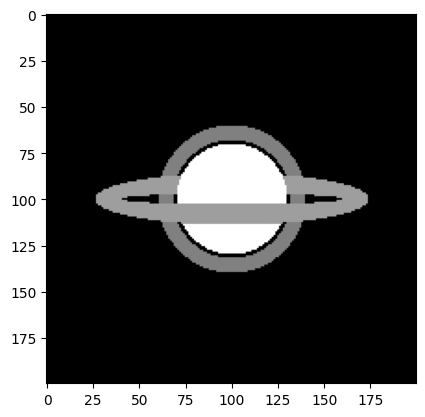

In [49]:
# you can change the seed to generate a slightly different phantom
random.seed(1)

img = np.zeros((200, 200))
intensity=20

# Circular disks #######
rr_disc11, cc_disc11 = draw.disk((100, 100), 40, shape=img.shape)
rr_disc22, cc_disc22 = draw.disk((100, 100), 32, shape=img.shape)

# Get the difference between the two disks to create a ring
mask_disc = np.zeros_like(img, dtype=bool)
mask_disc[rr_disc11, cc_disc11] = True
mask_disc[rr_disc22, cc_disc22] = False
img[mask_disc] = 0.20

#######################


# Ellipses ############
rr_outer, cc_outer = draw.ellipse(100, 100, 14, 74, shape=img.shape)
rr_inner, cc_inner = draw.ellipse(100, 100, 3, 60, shape=img.shape)

# Remove the inner ellipse from the outer ellipse
mask = np.zeros_like(img, dtype=bool)
mask[rr_outer, cc_outer] = True
mask[rr_inner, cc_inner] = False

mask_overlap = (mask_disc & mask) & (np.arange(img.shape[0])[:, None] > 100)
mask_disc = mask & ~mask_overlap
img[mask] = 0.25

#######################

# Black Hole ############
rr_disc, cc_disc = draw.disk((100, 100), 30, shape=img.shape)
mask_disc = np.zeros_like(img, dtype=bool)
mask_disc[rr_disc, cc_disc] = True

# For all heights smaller larger than 100 and where the disk mask overlaps with the elipse maks set the values to false
mask_overlap = (mask_disc & mask) & (np.arange(img.shape[0])[:, None] > 100)
mask_disc = mask_disc & ~mask_overlap
img[mask_disc] = 0.4

########################

img = img*255
img[img > 255] = 255
img[img < 0] = 0
img = img.astype(np.int16)

plt.imshow(img, cmap='gray')
plt.show()

## Utility functions

In [50]:
def project_from_2D(phantom_id, vol_geom, n_projections,
                    n_detectors, detector_spacing, angles,
                    noise_factor=None, save_dir=None, use_gpu=False):
        """ Creates projection for the given input data.

            Parameters:
                - phantom_data: numpy array containing the 2D phantom.
                - n_projections: defines the number of projections
                    (number of angles from where to sample measurements
                - detector_spacing: pixel size
                - angles:
                - noise_factor:
                - save_dir: path of the directory to save image representation
                    of projections, when defined. To be passed as a string.
                - use_gpu: (boolean) set to True to use gpu.

            Returns:
                projector_id, sinogram_id and sinogram matrix
        """

        # create projection geometry
        proj_geom = astra.create_proj_geom('parallel', detector_spacing,
                                            n_detectors, angles)
        # choose projector
        if use_gpu:
            proj_id = astra.create_projector('cuda', proj_geom, vol_geom)
        else:
            proj_id = astra.create_projector('linear', proj_geom, vol_geom)
        sino_id, sinogram = astra.creators.create_sino(phantom_id, proj_id)
        # Apply Poisson noise.
        if noise_factor != None:
            sinogram += np.random.poisson(lam=noise_factor, size=sinogram.shape)
            sino_id = astra.data2d.create('-sino', proj_geom, sinogram)
        # Save projections as images, if directory has been defined.
        if save_dir != None:
            if save_dir[-1] != '/':
                save_dir += '/'
            if not isdir(save_dir):
                mkdir(save_dir)
            proj_for_img = np.round(sinogram * (2**8- 1)).astype(np.uint8)
            for i in range(n_projections):
                Image.fromarray(proj_for_img[i]).save(save_dir+f'proj_{i}.png')

        return proj_id, sino_id, sinogram

def SART(vol_geom, vol_data, projector_id, sino_id, iters=2000, use_gpu=False):
        """ Simultaneous Algebraic Reconstruction Technique (SART) with
            randomized scheme. Used from DART as the continious update step.
        """
        # create starting reconstruction
        rec_id = astra.data2d.create('-vol', vol_geom, data=vol_data)
        # define SART configuration parameters
        alg_cfg = astra.astra_dict('SART_CUDA' if use_gpu else 'SART')
        alg_cfg['ProjectorId'] = projector_id
        alg_cfg['ProjectionDataId'] = sino_id
        alg_cfg['ReconstructionDataId'] = rec_id
        alg_cfg['option'] = {}
        alg_cfg['option']['MinConstraint'] = 0
        alg_cfg['option']['MaxConstraint'] = 255
        # define algorithm
        algorithm_id = astra.algorithm.create(alg_cfg)
        # run the algirithm
        astra.algorithm.run(algorithm_id, iters)
        # create reconstruction data
        rec = astra.data2d.get(rec_id)

        return rec_id, rec

## Computation

In [51]:
# measurement parameters
n_projections = 250
n_detectors = 512
det_spacing = 1
noise_factor = None
angles = np.linspace(0, 180, n_projections)
rec_alg = 'SART_CUDA'
rec_iters = 10000

# open phantom
img_width, img_height = img.shape
gray_lvls = np.unique(img).astype(np.float16)
img_width, img_height = img.shape

# prepare data for measurements
img = np.array(Image.fromarray(img), dtype=np.uint8)
img_width, img_height = img.shape
gray_lvls = np.unique(img).astype(np.float16)
vol_geom = astra.creators.create_vol_geom([img_width,img_height])
phantom_id = astra.data2d.create('-vol', vol_geom, data=img)

# make measurements
projector_id, sino_id, sinogram = project_from_2D(phantom_id=phantom_id,
                                                vol_geom=vol_geom,
                                                n_projections=n_projections,
                                                n_detectors=n_detectors,
                                                detector_spacing=det_spacing,
                                                angles=angles,
                                                noise_factor=noise_factor,
                                                use_gpu=True)

proj_geom = astra.create_proj_geom('parallel', det_spacing,
                                        n_detectors, angles)



Mean absolute pixel error: 0.109


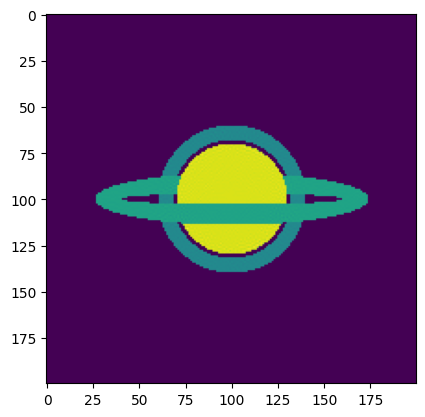

In [52]:
_, sart_res = SART(vol_geom,0,projector_id,sino_id,
                    iters=rec_iters, use_gpu=True)
print(f"Mean absolute pixel error: {np.abs(img - sart_res).mean():.3f}")
plt.imshow(sart_res)